## Install Dependencies
### Penjelasan Instalasi Dependensi

- **NumPy (`np`)**  
  Pustaka ini digunakan untuk melakukan komputasi numerik, seperti operasi pada array atau matriks.

- **Pandas (`pd`)**  
  Pustaka ini digunakan untuk memanipulasi dan menganalisis data, terutama yang berbentuk tabel (DataFrame).

- **Matplotlib (`plt`)**  
  Pustaka ini digunakan untuk membuat visualisasi data, seperti grafik garis, batang, atau diagram.

- **TensorFlow (`tf`)**  
  Pustaka ini digunakan untuk membangun dan melatih model machine learning, khususnya deep learning.  

In [10]:
# Import Library yang Dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

## Open Google Drive

### Cara Membuka Google Drive di Google Colab

1. **Mount Google Drive**  
   Hubungkan Google Drive ke Colab menggunakan perintah berikut:  
   `from google.colab import drive`  
   `drive.mount('/content/drive')`

2. **Otentikasi**  
   - Klik tautan otentikasi yang muncul.  
   - Login dengan akun Google.  
   - Salin dan tempel kode otentikasi di Colab.

3. **Akses File**  
   File Google Drive akan tersedia di:  
   `/content/drive/MyDrive`  

Gunakan perintah `!ls /content/drive/MyDrive` untuk melihat isi folder.

In [11]:
# Open Drive
from google.colab import drive
drive.mount('/content/drive')

# Change the working directory to the desired folder in your Google Drive
import os
os.chdir("/content/drive/MyDrive/KP_Pak_Mahas_Fix/CNN_Aksara/data")

# Now you can list files in the directory to verify
!ls


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Open Folder Dataset


In [12]:
# Change the working directory to the desired folder in your Google Drive
import os
os.chdir("/content/drive/MyDrive/KP_Pak_Mahas_Fix/CNN_Aksara/data")

# Now you can list files in the directory to verify
!ls

ba  da	 ga  ja  la	  LICENSE.md  na   nya	ra	   sa  tha  ya
ca  dha  ha  ka  LICENSE  ma	      nga  pa	README.md  ta  wa


#### Copy Directory of Train Data


In [13]:
# Copy Directory of Train Data

# Define the source directory in Google Drive
source_dir = "/content/drive/MyDrive/KP_Pak_Mahas_Fix/CNN_Aksara/data"

# Define the target directory in Colab's workspace
target_dir = "/content/train_data"

# Create the target directory if it doesn't exist
os.makedirs(target_dir, exist_ok=True)

# Copy files from Google Drive to Colab's directory
import shutil
shutil.copytree(source_dir, target_dir, dirs_exist_ok=True)

# Change the working directory to the target directory
os.chdir(target_dir)

# List files in the target directory to verify
!ls


ba  da	 ga  ja  la	  LICENSE.md  na   nya	ra	   sa  tha  ya
ca  dha  ha  ka  LICENSE  ma	      nga  pa	README.md  ta  wa


#### Copy Directory of Test Data


In [15]:
# Define the source directory in Google Drive
source_dir = "/content/drive/MyDrive/KP_Pak_Mahas_Fix/CNN_Aksara/data-test"

# Define the target directory in Colab's workspace
target_dir = "/content/test_data"

# Create the target directory if it doesn't exist
os.makedirs(target_dir, exist_ok=True)

# Copy files from Google Drive to Colab's directory
import shutil
shutil.copytree(source_dir, target_dir, dirs_exist_ok=True)

# Change the working directory to the target directory
os.chdir(target_dir)

# List files in the target directory to verify
!ls


ba  ca	da  dha  ga  ha  ja  ka  la  ma  na  nga  nya  pa  ra  sa  ta  tha  wa	ya


## Konfigurasi Direktori

### Cleaning Data & Load Data

In [16]:
data_dir = 'train_data'

In [24]:
from PIL import Image
import os

def remove_corrupted_images(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith(('jpg', 'jpeg', 'png')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()  # Verifikasi bahwa gambar tidak rusak
                except (IOError, SyntaxError):
                    print(f'Menghapus gambar yang rusak: {file_path}')
                    os.remove(file_path)  # Hapus gambar yang rusak

# Jalankan fungsi pada direktori yang berisi gambar-gambar Anda
remove_corrupted_images('/content/train_data')  # Ganti dengan path direktori Anda


In [25]:
from PIL import Image
import os

def check_images(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith(('jpg', 'jpeg', 'png')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except (IOError, SyntaxError) as e:
                    print('Bad file:', file_path)

check_images('/content/train_data')  # Ganti dengan path direktori Anda


In [26]:
import os

base_dir = '/content/train_data'

dirs = {char+'_dir': os.path.join(base_dir, char) for char in ['ha', 'na', 'ca', 'ra', 'ka', 'da', 'ta', 'sa', 'wa', 'la', 'pa', 'dha', 'ja', 'ya', 'nya', 'ma', 'ga', 'ba', 'tha', 'nga']}
ha_dir = os.path.join(base_dir, 'ha')
na_dir = os.path.join(base_dir, 'na')
ca_dir = os.path.join(base_dir, 'ca')
ra_dir = os.path.join(base_dir, 'ra')
ka_dir = os.path.join(base_dir, 'ka')
da_dir = os.path.join(base_dir, 'da')
ta_dir = os.path.join(base_dir, 'ta')
sa_dir = os.path.join(base_dir, 'sa')
wa_dir = os.path.join(base_dir, 'wa')
la_dir = os.path.join(base_dir, 'la')
pa_dir = os.path.join(base_dir, 'pa')
dha_dir = os.path.join(base_dir, 'dha')
ja_dir = os.path.join(base_dir, 'ja')
ya_dir = os.path.join(base_dir, 'ya')
nya_dir = os.path.join(base_dir, 'nya')
ma_dir = os.path.join(base_dir, 'ma')
ga_dir = os.path.join(base_dir, 'ga')
ba_dir = os.path.join(base_dir, 'ba')
tha_dir = os.path.join(base_dir, 'tha')
nga_dir = os.path.join(base_dir, 'nga')

for char, char_dir in dirs.items():
    print(f"total training {char} images:", len(os.listdir(char_dir)))


ha_files = os.listdir(ha_dir)
print(ha_files[:10])

na_files = os.listdir(na_dir)
print(na_files[:10])

ca_files = os.listdir(ca_dir)
print(ca_files[:10])

ra_files = os.listdir(ra_dir)
print(ra_files[:10])

ka_files = os.listdir(ka_dir)
print(ka_files[:10])

da_files = os.listdir(da_dir)
print(da_files[:10])

ta_files = os.listdir(ta_dir)
print(ta_files[:10])

sa_files = os.listdir(sa_dir)
print(sa_files[:10])

wa_files = os.listdir(wa_dir)
print(wa_files[:10])

la_files = os.listdir(la_dir)
print(la_files[:10])

pa_files = os.listdir(pa_dir)
print(pa_files[:10])

dha_files = os.listdir(dha_dir)
print(dha_files[:10])

ja_files = os.listdir(ja_dir)
print(ja_files[:10])

ya_files = os.listdir(ya_dir)
print(ya_files[:10])

nya_files = os.listdir(nya_dir)
print(nya_files[:10])

ma_files = os.listdir(ma_dir)
print(ma_files[:10])

ga_files = os.listdir(ga_dir)
print(ga_files[:10])

ba_files = os.listdir(ba_dir)
print(ba_files[:10])

tha_files = os.listdir(tha_dir)
print(tha_files[:10])

nga_files = os.listdir(nga_dir)
print(nga_files[:10])

total training ha_dir images: 214
total training na_dir images: 212
total training ca_dir images: 212
total training ra_dir images: 208
total training ka_dir images: 223
total training da_dir images: 211
total training ta_dir images: 208
total training sa_dir images: 311
total training wa_dir images: 222
total training la_dir images: 211
total training pa_dir images: 219
total training dha_dir images: 210
total training ja_dir images: 210
total training ya_dir images: 211
total training nya_dir images: 210
total training ma_dir images: 212
total training ga_dir images: 210
total training ba_dir images: 238
total training tha_dir images: 209
total training nga_dir images: 233
['4693970800717150257_base64_5.png', 'ha61.mine.rm5.png', 'ha32.mine2.rm5.png', 'ha1.mine.rm10.png', 'ha81.mine.r10.png', '4694065538412229897_base64_5.png', 'ha81.mine.rm5.png', 'ha99.pred3.r5.png', 'ha0.meki.png', 'ha1.mine.r5.png']
['na33.mine2.png', 'na21.mine3.r10.png', 'na41.mine3.rm5.png', 'na53.mine2.rm5.pn

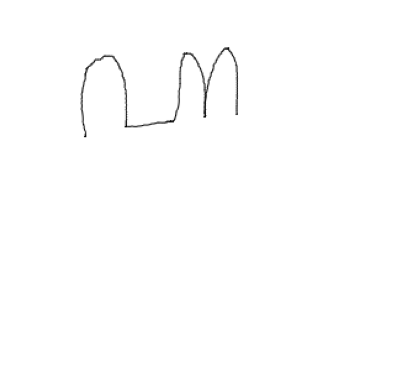

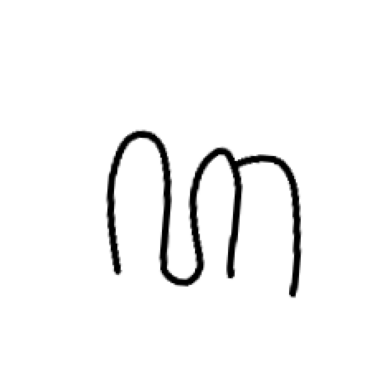

In [27]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pic_index = 2

next_ha = [os.path.join(ha_dir, fname)
                for fname in ha_files[pic_index-2:pic_index]]
next_na = [os.path.join(na_dir, fname)
                for fname in na_files[pic_index-2:pic_index]]

next_ca = [os.path.join(ca_dir, fname)
           for fname in ca_files[pic_index-2:pic_index]]
next_ra = [os.path.join(ra_dir, fname) for fname in ra_files[pic_index-2:pic_index]]
next_ka = [os.path.join(ka_dir, fname) for fname in ka_files[pic_index-2:pic_index]]
next_da = [os.path.join(da_dir, fname) for fname in da_files[pic_index-2:pic_index]]
next_ta = [os.path.join(ta_dir, fname) for fname in ta_files[pic_index-2:pic_index]]
next_sa = [os.path.join(sa_dir, fname) for fname in sa_files[pic_index-2:pic_index]]
next_wa = [os.path.join(wa_dir, fname) for fname in wa_files[pic_index-2:pic_index]]
next_la = [os.path.join(la_dir, fname) for fname in la_files[pic_index-2:pic_index]]
next_pa = [os.path.join(pa_dir, fname) for fname in pa_files[pic_index-2:pic_index]]
next_dha = [os.path.join(dha_dir, fname) for fname in dha_files[pic_index-2:pic_index]]
next_ja = [os.path.join(ja_dir, fname) for fname in ja_files[pic_index-2:pic_index]]
next_ya = [os.path.join(ya_dir, fname) for fname in ya_files[pic_index-2:pic_index]]
next_nya = [os.path.join(nya_dir, fname) for fname in nya_files[pic_index-2:pic_index]]
next_ma = [os.path.join(ma_dir, fname) for fname in ma_files[pic_index-2:pic_index]]
next_ga = [os.path.join(ga_dir, fname) for fname in ga_files[pic_index-2:pic_index]]
next_ba = [os.path.join(ba_dir, fname) for fname in ba_files[pic_index-2:pic_index]]
next_tha = [os.path.join(tha_dir, fname) for fname in tha_files[pic_index-2:pic_index]]
next_nga = [os.path.join(nga_dir, fname) for fname in nga_files[pic_index-2:pic_index]]


for i, img_path in enumerate(next_ha):
  img = mpimg.imread(img_path)
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

In [29]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_width, img_height = 150, 150
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.2
)

train_dataset = train_datagen.flow_from_directory(
    '/content/train_data',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='sparse',
    subset='training'
)

validation_dataset = train_datagen.flow_from_directory(
    '/content/test_data',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation'
)


Found 3522 images belonging to 20 classes.
Found 1 images belonging to 20 classes.


In [30]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

model = tf.keras.models.Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),

    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),

    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(20, activation='softmax')
])

# Print the model summary
model.summary()

# Set the training parameters
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 15, 15, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 5, 5, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 5, 5, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │              

 Total params: 2,633,940 (10.05 MB)

 Trainable params: 2,630,932 (10.04 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

img_width = 150
img_height = 150

from tensorflow.keras.utils import image_dataset_from_directory

# Membuat dataset pelatihan dan validasi
train_dataset = image_dataset_from_directory(
    '/content/train_data',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_width, img_height),
    batch_size=32)

validation_dataset = image_dataset_from_directory(
    '/content/test_data',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_width, img_height),
    batch_size=32)

# Callback untuk early stopping, reduce learning rate, dan model checkpoint
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

# Training model
history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)


# Evaluasi model
loss, accuracy = model.evaluate(validation_dataset)
print(f'Validation accuracy: {accuracy:.2f}')

Found 4393 files belonging to 20 classes.
Using 3515 files for training.
Found 55 files belonging to 20 classes.
Using 11 files for validation.
Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 387s 3s/step - accuracy: 0.1053 - loss: 4.7858 - val_accuracy: 0.2727 - val_loss: 6.0347 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 430s 3s/step - accuracy: 0.3075 - loss: 3.4589 - val_accuracy: 0.2727 - val_loss: 4.9202 - learning_rate: 0.0010
Epoch 3/100
 10/110 ━━━━━━━━━━━━━━━━━━━━ 5:30 3s/step - accuracy: 0.3772 - loss: 2.9605

In [ ]:
import matplotlib.pyplot as plt

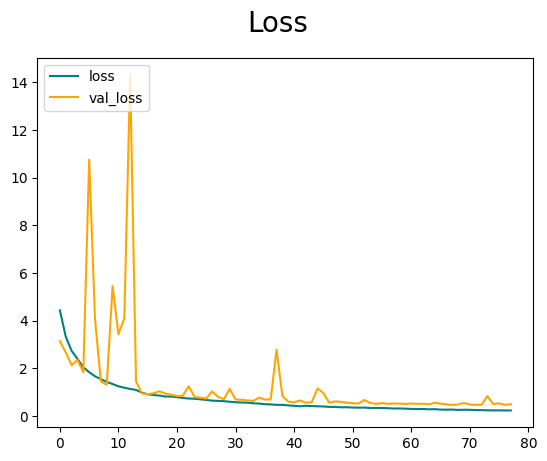

In [ ]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

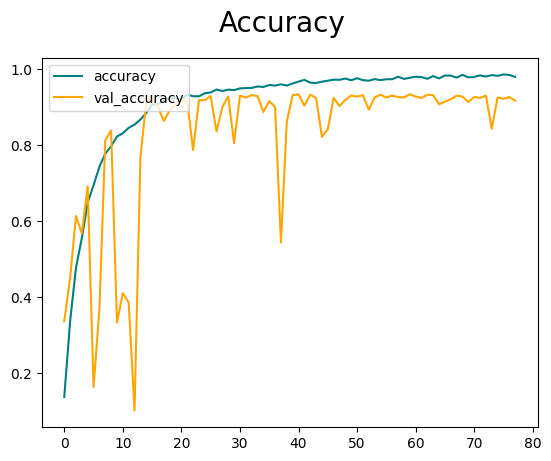

In [ ]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Fungsi untuk memuat dan mempersiapkan gambar
def load_and_prepare_image(file_path, img_width, img_height):
    img = image.load_img(file_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Membuat batch yang terdiri dari satu gambar
    return img_array

# Memprediksi gambar baru
file_path = 'nya.png'  # Ganti dengan path ke gambar yang ingin diprediksi
img_width, img_height = 150, 150  # Ganti dengan dimensi yang sesuai dengan model
img_array = load_and_prepare_image(file_path, img_width, img_height)

predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)

# Mendapatkan nama kelas dari class _names
predicted_class_name = train_dataset.class_names[predicted_class_index[0]]

print(f"Prediksi huruf hijaiyah: {predicted_class_name}")


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
model.save('model.keras')

NameError: name 'model' is not defined

In [ ]:
# Muat model yang telah disimpan dengan compile=False
model = tf.keras.models.load_model('modelC.keras', compile=False)

# Konversi model ke TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model TensorFlow Lite
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp7pocvbfp\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp7pocvbfp\assets


OSError: Unable to synchronously open file (file signature not found)